### Generate the data

In [10]:
import numpy as np

np.random.seed(42)

X = np.sort(5 * np.random.rand(200, 1), axis=0)

y = np.sin(X).ravel()

# add noise
y[::5] += 0.5 - np.random.rand(40)


### Plot the data

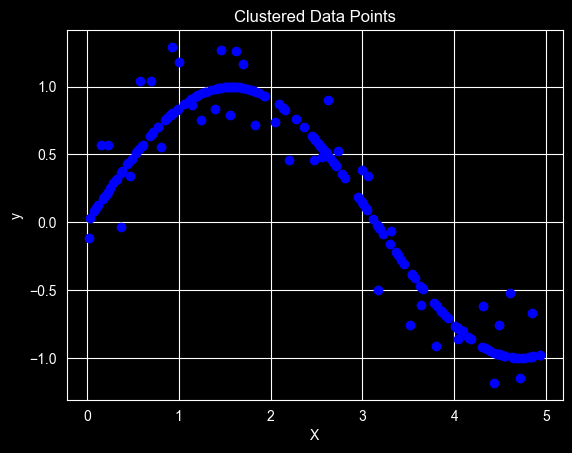

In [11]:
from matplotlib import pyplot as plt

plt.scatter(X, y, color="blue")
plt.title("Clustered Data Points")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### Train using decission tree

In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth":[2,3,4,5,6],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

grid = GridSearchCV(
    DecisionTreeRegressor(),
    param_grid,
    cv=5
)

grid.fit(X,y)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}


### Predict the x_test

In [15]:
from sklearn.metrics import r2_score

X_test = np.linspace(0,5,500).reshape(-1,1)
y_test = np.sin(X_test).ravel()

y_pred = best_model.predict(X_test)
best_model.score(X_test,y_test)


0.9853771227248569

### Draw regression boundary

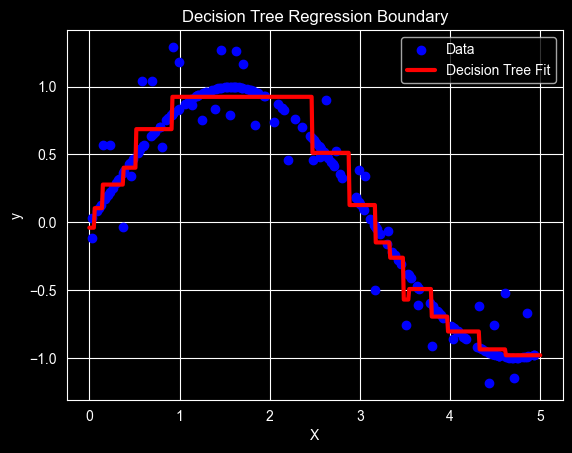

In [6]:
plt.scatter(X, y, color="blue", label="Data")
plt.plot(X_test, y_pred, color="red", linewidth=3, label="Decision Tree Fit")

plt.title("Decision Tree Regression Boundary")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### Decission tree

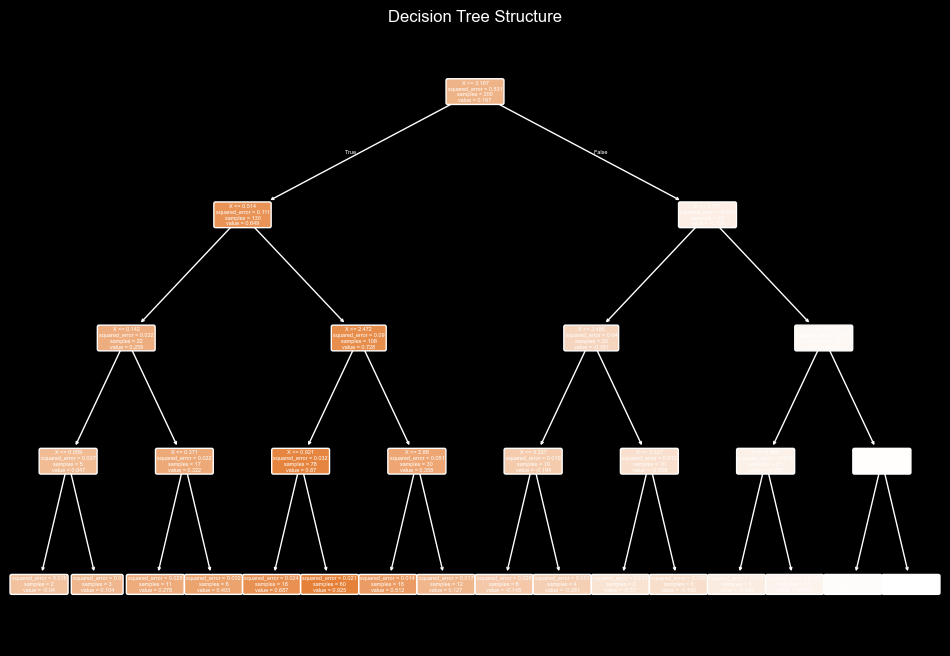

In [8]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))

plot_tree(
    best_model,
    filled=True,
    rounded=True,
    feature_names=["X"]
)

plt.title("Decision Tree Structure")
plt.show()